In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('CSV_FILES/removed.csv')
df

,Unnamed: 0,age,gender,item purchased,category,purchase amount (usd),location,size,color,season,review rating,subscription status,shipping type,discount applied,previous purchases,payment method,frequency of purchases
0,0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,Venmo,Weekly
3896,3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,Bank Transfer,Bi-Weekly
3897,3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,24,Venmo,Quarterly
3898,3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,24,Venmo,Weekly


In [3]:
df['frequency of purchases'].value_counts()

frequency of purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

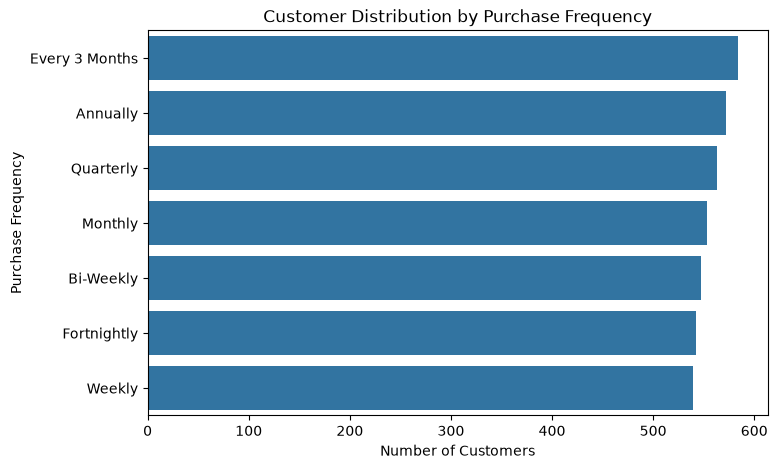

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='frequency of purchases',
    data=df,
    order=df['frequency of purchases'].value_counts().index
)

plt.title('Customer Distribution by Purchase Frequency')
plt.xlabel('Number of Customers')
plt.ylabel('Purchase Frequency')

plt.show()

In [5]:
frequency_avg = (
    df.groupby('frequency of purchases')['purchase amount (usd)']
      .mean()
      .sort_values(ascending=False)
)

frequency_avg

frequency of purchases
Bi-Weekly         60.694698
Annually          60.173077
Every 3 Months    60.082192
Quarterly         59.984014
Monthly           59.330922
Fortnightly       59.053506
Weekly            58.972171
Name: purchase amount (usd), dtype: float64

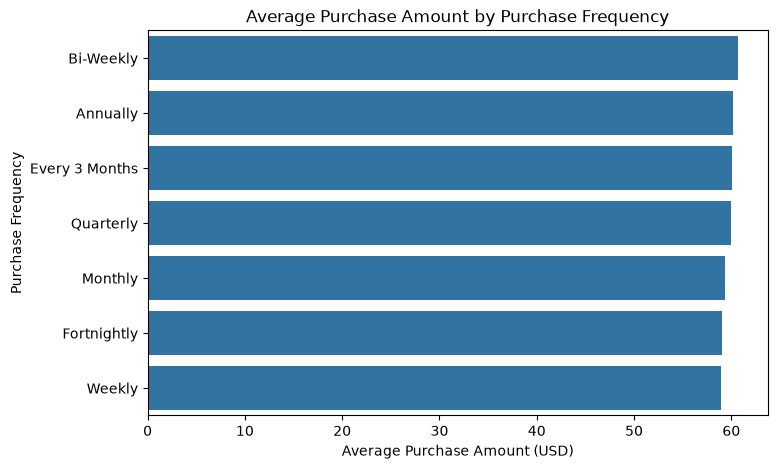

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=frequency_avg.values,
    y=frequency_avg.index
)

plt.title('Average Purchase Amount by Purchase Frequency')
plt.xlabel('Average Purchase Amount (USD)')
plt.ylabel('Purchase Frequency')

plt.show()

In [7]:
frequency_revenue = (
    df.groupby('frequency of purchases')['purchase amount (usd)']
      .sum()
      .sort_values(ascending=False)
)

frequency_revenue

frequency of purchases
Every 3 Months    35088
Annually          34419
Quarterly         33771
Bi-Weekly         33200
Monthly           32810
Fortnightly       32007
Weekly            31786
Name: purchase amount (usd), dtype: int64

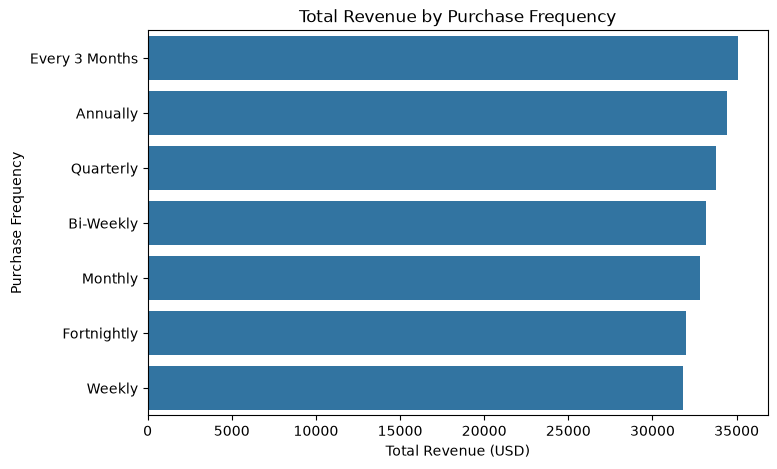

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=frequency_revenue.values,
    y=frequency_revenue.index
)

plt.title('Total Revenue by Purchase Frequency')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Purchase Frequency')

plt.show()

Revenue is relatively evenly distributed across purchase frequency groups. Customers purchasing every three months contribute the highest total revenue, while weekly purchasers contribute the least, although the overall differences are modest.